# Week 4 Day 5 Lab

### Linear Regression
Linear regression is a statistical method of finding the *line of best fit*. What we hope is that this line gives us enough information about the relationship between two variables that we can *predict* (at least somewhat) a value for a given input.

Typically,

- **X** is called the **independent variable** (or predictor).
- **Y** is called the **dependent variable** (or response).

The goal is to find the line that best describes the relationship between X and Y.

In [7]:
import numpy as np
import matplotlib.pyplot as plt


### Linear Regression Equation

The equation of a simple linear regression line is

$$
y = mx + b
$$

where

- $m$ = slope
- $b$ = y-intercept

In statistics, this equation is often written as

$$
\hat{y} = \beta_0 + \beta_1x
$$

where

- $ \hat{y}$ is the predicted value,
- $\beta_0$ is the intercept,
- $\beta_1$ is the slope.

Consider the following dataset:

In [8]:
hours = np.array([1,2,3,4,5,6,7,8,9,10])
heat = np.array([52,50,63,66,70,76,81,90,91,95])

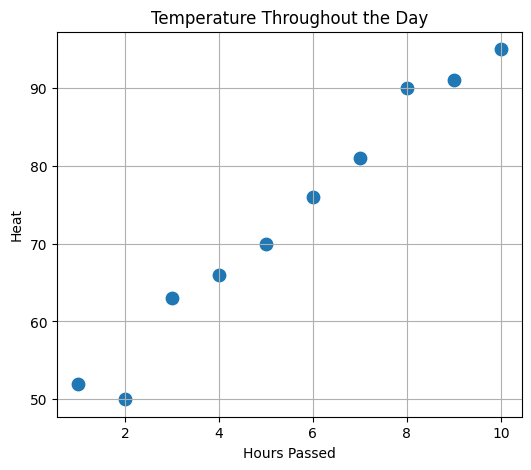

In [9]:
plt.figure(figsize=(6,5))

plt.scatter(hours,
            heat,
            s=80)

plt.xlabel("Hours Passed")
plt.ylabel("Heat")
plt.title("Temperature Throughout the Day")

plt.grid()

plt.show()

While the relationship above is *not quite* linear, the relationship behaves somewhat linearly.

In [10]:
m, b = np.polyfit(hours,
                  heat,
                  1)

print("Slope:", m)
print("Intercept:", b)

Slope: 5.212121212121211
Intercept: 44.73333333333329


What the slope tells us is that as an hour passes, the model *predicts* a 5.2 degree increase. What the intercept tells us is that the model *predicts* a temperature of 44.7 at the start. Not that either of these are true. But, with the given data, we assume this and test whether that is indeed true.

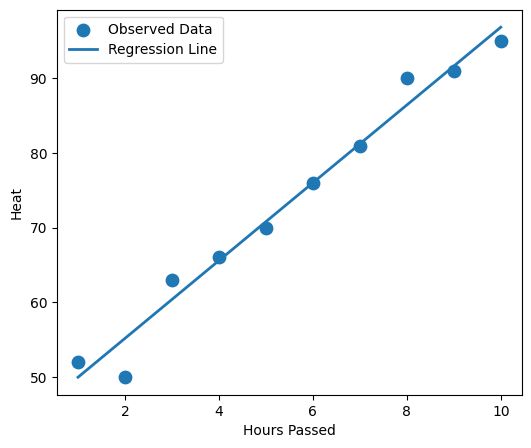

In [11]:
plt.figure(figsize=(6,5))

plt.scatter(hours,
            heat,
            s=80,
            label="Observed Data")

plt.plot(hours,
         m*hours+b,
         linewidth=2,
         label="Regression Line")

plt.xlabel("Hours Passed")
plt.ylabel("Heat")

plt.legend()

plt.show()

### Prediction in Linear Regression

Now that we a linear estimation, we can make predictions:

In [12]:
m*24 + b # temperature in 24 hours

np.float64(169.82424242424236)

In [13]:
m*np.array([24,48])+b # temperature in one day and then the next

array([169.82424242, 294.91515152])

### Residuals
A **residual** is defined as
$$
\text{Residual}=\text{Observed}-\text{Predicted}
$$

Residuals tell us how far each observation is from the regression line. Linear regression works by *minimizing* these. To compute them:

In [15]:
predicted = m*hours + b
residuals = heat - predicted
print(residuals)

[ 2.05454545 -5.15757576  2.63030303  0.41818182 -0.79393939 -0.00606061
 -0.21818182  3.56969697 -0.64242424 -1.85454545]


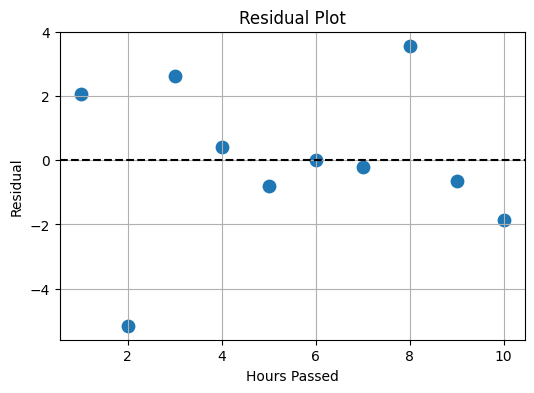

In [16]:
plt.figure(figsize=(6,4))

plt.scatter(hours,
            residuals,
            s=80)
plt.axhline(0,
            color="black",
            linestyle="--")

plt.xlabel("Hours Passed")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid()

plt.show()

A good regression model has residuals randomly scattered around zero.

Regression is closely related to correlation!

In [17]:
np.corrcoef(hours,heat)

array([[1.        , 0.98791075],
       [0.98791075, 1.        ]])

Interpretation:

- Close to **1** → strong positive relationship.
- Close to **0** → weak relationship.
- Close to **-1** → strong negative relationship.


### Testing the Strength of Model

A simple statistic (called $R^2$) is simply the square of the correlation we defined last time

$$
R^2=r^2=\left(\frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2}\sqrt{\sum(y_i-\bar{y})^2}}\right)^2
$$

If

```text
R² = 0.94
```

then we say approximately **94%** of the variation in heat is explained by hours passed.

In [18]:
rsquared = np.corrcoef(hours, heat)[0,1]**2
print(rsquared)

0.9759676542466995


### Try it for yourself

1. Pick a data set from GitHub and pick two features you like
2. Plot the data set
3. Perform linear regression and re-plot with regression line
4. Predict values that aren't within the dataset
5. Compute the residuals and plot them to see if they are randomly spread around zero
6. Compute the $R^2$ statistic for your model

In [20]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv('wine.csv')
df.head()

Saving wine.csv to wine.csv


,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
#1 wine data, "Alcohol vs Color intensity"

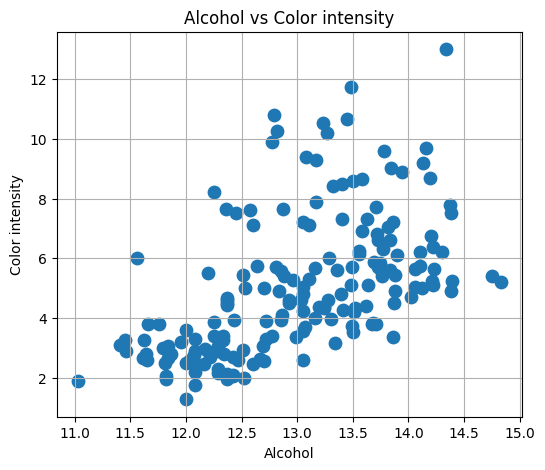

In [21]:
#2
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

x = df["Alcohol"]
y = df["Color intensity"]

plt.figure(figsize=(6,5))

plt.scatter(x, y, s=80)

plt.xlabel("Alcohol")
plt.ylabel("Color intensity")
plt.title("Alcohol vs Color intensity")

plt.grid()

plt.show()

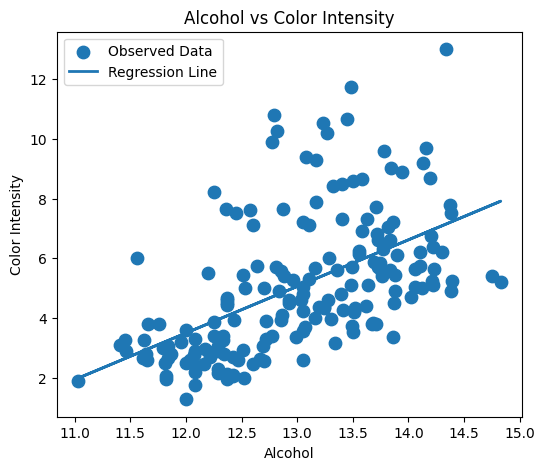

In [32]:
#3
m, b = np.polyfit(df["Alcohol"], df["Color intensity"], 1)

plt.figure(figsize=(6,5))

plt.scatter(df["Alcohol"],
            df["Color intensity"],
            s=80,
            label="Observed Data")

plt.plot(df["Alcohol"],
         m*df["Alcohol"] + b,
         linewidth=2,
         label="Regression Line")

plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")
plt.title("Alcohol vs Color Intensity")

plt.legend()

plt.show()

In [42]:
#4
new_alcohol = np.array([11.5, 13.0, 15.0])
predicted_color = m * new_alcohol + b
print(predicted_color)

[2.71679497 5.0571257  8.17756667]


0     -1.336197
1     -0.989170
2      0.373239
3      0.605372
4     -1.111579
         ...   
173    1.535118
174    1.618786
175    4.721615
176    3.977637
177    2.379825
Length: 178, dtype: float64


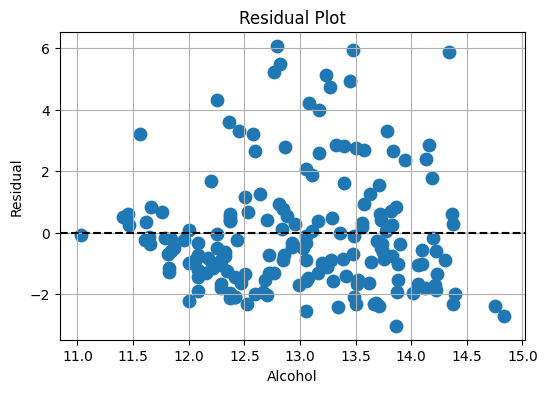

In [43]:
#5
predicted = m * df["Alcohol"] + b
residuals = df["Color intensity"] - predicted
print(residuals)

plt.figure(figsize=(6,4))

plt.scatter(df["Alcohol"],
            residuals,
            s=80)

plt.axhline(0,
            color="black",
            linestyle="--")

plt.xlabel("Alcohol")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid()

plt.show()

In [44]:
predicted = m * df["Alcohol"] + b

ss_res = np.sum((df["Color intensity"] - predicted) ** 2)
ss_tot = np.sum((df["Color intensity"] - np.mean(df["Color intensity"])) ** 2)
r2 = 1 - (ss_res / ss_tot)
print("R^2 =", r2)

R^2 = 0.2985138336694634
